### 데이터의 불균형 문제

- 정상을 정확하게 분류하는 것과 이상을 정확하게 분류하는 것 중 이상을 정확하게 분류하는 것이 더 중요하다.
- 일반적으로는 정상의 데이터가 이상의 데이터보다 많다.
- 데이터의 불균형이 발생할 수 있다.
- target 데이터에서 0(정상), 1(이상) 중에 0을 판단을 더 많이 하게 되는 경우가 발생하면 예측력이 떨어진다.
- 소수 데이터의 중요도가 낮게 판단되어 실제 모델에서는 해당하는 예측이 적게 발생
- 다수 데이터와 소수 데이터를 특정 비율로 조절해주는 샘플링 기법이 존재 (언더 샘플링, 오버 샘플링)
- 샘플링을 사용하기 위한 라이브러리 설치 (imbalanced-learn)

In [2]:
# !pip install imbalanced-learn

- 언더 샘플링
    - 다수의 라벨을 가진 데이터를 샘플링하여 소수의 데이터의 수준으로 감소시키는 방법
    - 데이터 불균형 문제는 해결이 되지만 전체 데이터의 개수가 감소하여 학습의 성능이 떨어질 수 있다.

In [3]:
import pandas as pd
from sklearn.datasets import make_classification
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler

In [4]:
# 머신러닝에서는 독립 변수와 종속 변수를 이용
# make_classification() 함수는 데이터가 불균형한 랜덤 데이터를 생성
    # 결과를 독립변수, 종속변수 따로 제공

# 불균형 데이터셋 생성
x, y = make_classification(
    n_samples= 1000,
    n_features= 5,
    weights= [0.9],
    flip_y= 0
)

In [5]:
Counter(y)

Counter({np.int64(0): 901, np.int64(1): 99})

In [6]:
df = pd.DataFrame(x)
df['target'] = y

df.head()

,0,1,2,3,4,target
0,1.921543,-1.678665,-0.933106,0.737711,1.617702,0
1,0.866746,-0.512473,-0.580816,0.732153,0.778076,0
2,0.572531,-0.617819,-1.575599,0.027785,0.458739,0
3,1.918790,-1.358680,0.511738,1.254963,1.678172,0
4,1.053922,-0.969994,0.345164,0.324182,0.877528,0


In [7]:
# RandomUnderSampler 라는 class를 생성

undersampler = RandomUnderSampler()

In [8]:
under_x, under_y = undersampler.fit_resample(x, y)

In [9]:
Counter(under_y)

Counter({np.int64(0): 99, np.int64(1): 99})

In [ ]:
# undersampler에서 데이터의 비율을 변경
# class 생성할 때 비율을 지정
# sampling_strategy 매개변수 → 소수 데이터의 비율을 의미
    # 0.5면 2배

undersampler2 = RandomUnderSampler(sampling_strategy=0.3)

under_x2, under_y2 = undersampler2.fit_resample(x, y)

In [15]:
Counter(under_y2)

Counter({np.int64(0): 330, np.int64(1): 99})

- 오버 샘플링
    - 소수 데이터를 다수 데이터 개수만큼 증가시켜 학습에 사용하기 위한 방법
    - 데이터의 손실이 없기 때문에 일반적으로 언더 샘플링보다 자주 사용

- 랜덤 오버 샘플링
    - 소수의 데이터를 단순 복제하여 다수의 데이터와의 비율을 맞춰주는 과정
    - 데이터 단순 복제: 데이터의 분포가 변하지는 않지만, 과적합이 우려됨
        - 하지만 데이터 불균형 문제를 해결하는 것이 더 중요

In [16]:
from imblearn.over_sampling import RandomOverSampler

In [17]:
oversampler = RandomOverSampler()

In [18]:
over_x, over_y = oversampler.fit_resample(x, y)

In [19]:
Counter(over_y)

Counter({np.int64(0): 901, np.int64(1): 901})

In [21]:
# 소수의 데이터 비율을 다수의 반 정도로 샘플링
oversampler2 = RandomOverSampler(sampling_strategy=0.5)

In [22]:
over_x2, over_y2 = oversampler2.fit_resample(x, y)

In [23]:
Counter(over_y2)

Counter({np.int64(0): 901, np.int64(1): 450})

- SMOTE
    - 소수 데이터의 관측값에 대한 K개의 최근접 양수를 이웃으로 찾고, 관측 값과 이웃으로 선택된 값 사이에 임의의 새로운 데이터를 생성하는 방법

In [24]:
from imblearn.over_sampling import SMOTE

In [25]:
smote = SMOTE()

In [26]:
sm_x, sm_y = smote.fit_resample(x, y)

In [27]:
Counter(sm_y)

Counter({np.int64(0): 901, np.int64(1): 901})

In [28]:
# 실제 만들어진 샘플링 데이터의 분포를 확인

import matplotlib.pyplot as plt
import seaborn as sns

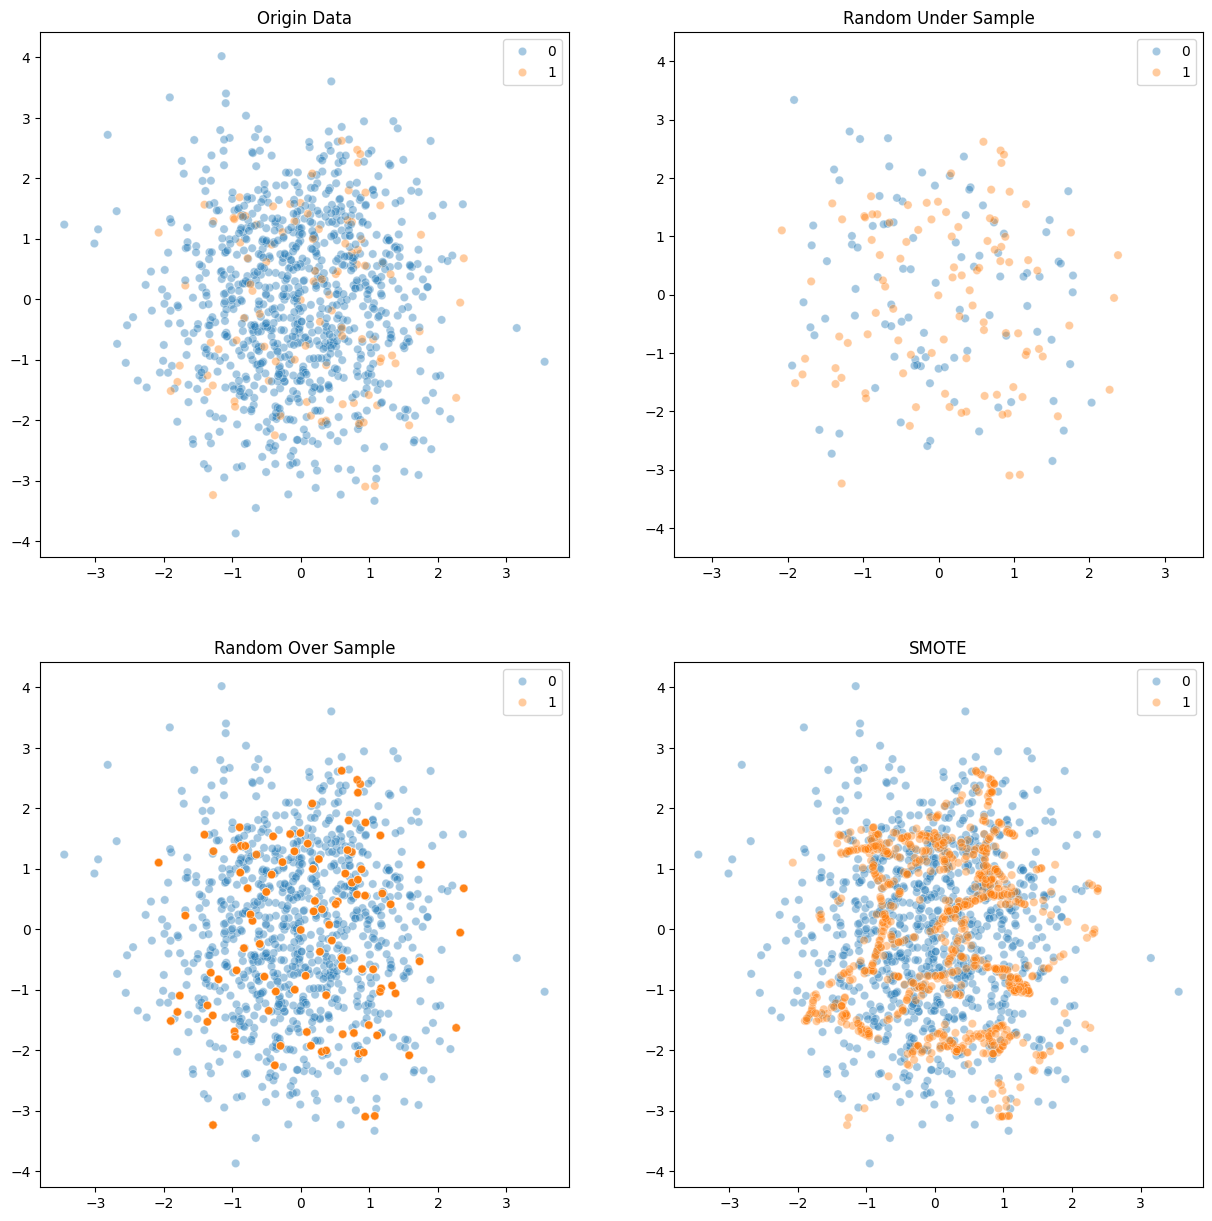

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15))

# 4개의 산점도 그래프 생성
sns.scatterplot(
    x = x[:, 2], y = x[:, 3], ax = axes[0][0], hue = y, alpha = 0.4
)

sns.scatterplot(
    x = under_x[:, 2], y = under_x[:, 3], ax = axes[0][1], hue = under_y, alpha = 0.4
)

sns.scatterplot(
    x = over_x[:, 2], y = over_x[:, 3], ax = axes[1][0], hue = over_y, alpha = 0.4
)

sns.scatterplot(
    x = sm_x[:, 2], y = sm_x[:, 3], ax = axes[1][1], hue = sm_y, alpha = 0.4
)

axes[0][0].set_title('Origin Data')
axes[0][1].set_title('Random Under Sample')
axes[0][1].set_xlim(-3.5, 3.5)
axes[0][1].set_ylim(-4.5, 4.5)
axes[1][0].set_title('Random Over Sample')
axes[1][1].set_title('SMOTE')

plt.show()